# Replication: Booth et al. (2006)
## *Lee-Carter Mortality Forecasting: A Multi-Country Comparison of Variants and Extensions*
### Demographic Research, Vol. 15, Article 9

This notebook replicates the forecast evaluation in Booth et al. (2006), comparing five mortality
forecasting methods across 10 developed countries.  All methods share the Lee-Carter decomposition

$$\ln m_{x,t} = a_x + b_x k_t + \varepsilon_{x,t}$$

but differ in fitting period, $k_t$ adjustment, and jump-off choice.

| Method | Fitting period | $k_t$ adjustment | Jump-off |
|--------|---------------|-----------------|---------|
| **LC** | Long (from `start_long`) | $D_t$ (total deaths) | Fitted |
| **LM** | 1950–1985 | $e(0)$ each year | Actual |
| **BMS** | Short (optimal linearity) | $D_{x,t}$ (age distribution) | Fitted |
| **HU** | 1950–1985 | None | — |
| **DJT** | 1950–1985 | None | Smoothed actual |

**Evaluation:** Fit to data up to 1985, forecast 1986–2006, compare with actual mortality.

## 1. Setup

In [20]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.stats import f_oneway

plt.rcParams.update({
    "figure.figsize": (12, 5), "figure.dpi": 110,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.grid": True, "axes.facecolor": "#EAEAF2",
    "grid.color": "white", "grid.linewidth": 0.8,
    "figure.facecolor": "white",
})

# ── Study parameters (Booth et al. 2006, Table 1) ───────────────────────────
COUNTRIES = [
    {"name": "Australia",        "code": "AUS",     "start_long": 1921},
    {"name": "Canada",           "code": "CAN",     "start_long": 1921},
    {"name": "Denmark",          "code": "DNK",     "start_long": 1900},
    {"name": "England & Wales",  "code": "GBRTENW", "start_long": 1922},
    {"name": "Finland",          "code": "FIN",     "start_long": 1900},
    {"name": "France",           "code": "FRATNP",  "start_long": 1900},
    {"name": "Italy",            "code": "ITA",     "start_long": 1900},
    {"name": "Norway",           "code": "NOR",     "start_long": 1900},
    {"name": "Sweden",           "code": "SWE",     "start_long": 1900},
    {"name": "Switzerland",      "code": "CHE",     "start_long": 1900},
]
SEXES      = ["male", "female"]
FIT_END    = 1985
EVAL_START = 1986
EVAL_END   = 2000
MAX_AGE    = 94   # paper groups 95+ together

## 2. Data

Data source: Human Mortality Database (HMD) — central death rates $m_{x,t}$ by single year of
age and calendar year, downloaded per country and sex and stored as parquet files in `data/`.

**Filters applied:**
- Ages $0$–$94$ (ages $\geq 95$ excluded as per the paper)
- Years from each country's `start_long` through $2006$ (evaluation end)

In [21]:
import os

def load_country_data(country_code, sex, start_long):
    """Load pre-downloaded HMD parquet, apply age and year filters."""
    path = os.path.join("data", f"{country_code}_{sex}.parquet")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found. Run download_hmd_data.py first."
        )
    df = pd.read_parquet(path)
    # Age filter: 0 to MAX_AGE
    df = df[df.index <= MAX_AGE]
    # Year filter: country start_long → EVAL_END
    valid_years = [y for y in df.columns if start_long <= y <= EVAL_END]
    df = df[valid_years]
    return df

# Load all 20 populations
mx_all = {}
missing = []
for c in COUNTRIES:
    for sex in SEXES:
        try:
            df = load_country_data(c["code"], sex, c["start_long"])
            mx_all[(c["name"], sex)] = df
            print(f"  {c['name']:20s} {sex}: ages {df.index[0]}-{df.index[-1]}, "
                  f"years {df.columns[0]}-{df.columns[-1]}")
        except FileNotFoundError as e:
            missing.append(str(e))

if missing:
    print("\nMISSING FILES:")
    for m in missing:
        print(" ", m)
else:
    print(f"\nLoaded {len(mx_all)} population datasets.")

  Australia            male: ages 0-94, years 1921-2000
  Australia            female: ages 0-94, years 1921-2000
  Canada               male: ages 0-94, years 1921-2000
  Canada               female: ages 0-94, years 1921-2000
  Denmark              male: ages 0-94, years 1900-2000
  Denmark              female: ages 0-94, years 1900-2000
  England & Wales      male: ages 0-94, years 1922-2000
  England & Wales      female: ages 0-94, years 1922-2000
  Finland              male: ages 0-94, years 1900-2000
  Finland              female: ages 0-94, years 1900-2000
  France               male: ages 0-94, years 1900-2000
  France               female: ages 0-94, years 1900-2000
  Italy                male: ages 0-94, years 1900-2000
  Italy                female: ages 0-94, years 1900-2000
  Norway               male: ages 0-94, years 1900-2000
  Norway               female: ages 0-94, years 1900-2000
  Sweden               male: ages 0-94, years 1900-2000
  Sweden               female: a

## 3. Core Functions

### 3.1 Period Life Expectancy

Given age-specific central death rates $m_x$, the standard life-table construction gives
life expectancy at birth $e_0$:

$$q_x = \frac{m_x}{1 + (1-a_x)m_x}, \qquad a_x = \begin{cases}0.1 & x=0 \\ 0.5 & x>0\end{cases}$$

$$l_{x+1} = l_x(1-q_x), \quad L_x = \frac{l_x + l_{x+1}}{2}, \quad T_x = \sum_{s\geq x} L_s, \quad e_0 = \frac{T_0}{l_0}$$

In [ ]:
def _a0_andreev(m0, sex):
    """Andreev-Kingkade (2015) age-0 fraction — formula used by HMD."""
    if sex == "male":
        return 0.330 if m0 >= 0.107 else 0.045 + 2.684 * m0
    else:
        return 0.350 if m0 >= 0.107 else 0.053 + 2.800 * m0

def life_expectancy(mx_vec, ages=None, sex='male'):
    """Period life expectancy at birth from central death rates."""
    mx = np.asarray(mx_vec, dtype=float)
    if ages is None:
        ages = np.arange(len(mx))
    n  = len(mx)
    ax = np.full(n, 0.5)
    age0_idx = np.where(ages == 0)[0]
    if len(age0_idx) > 0:
        ax[age0_idx[0]] = _a0_andreev(mx[age0_idx[0]], sex)
    qx = mx / (1 + (1 - ax) * mx)
    qx = np.minimum(qx, 1.0); qx[-1] = 1.0
    lx = np.ones(n + 1)
    for i in range(n):
        lx[i+1] = lx[i] * (1 - qx[i])
    Lx = (lx[:-1] + lx[1:]) / 2
    Lx[-1] = lx[-2] / mx[-1]   # open interval: constant-force assumption
    Tx = np.cumsum(Lx[::-1])[::-1]
    return Tx[0] / lx[0]

### 3.2 Lee-Carter SVD Estimation

The centred log-rate matrix $Z_{x,t} = \ln m_{x,t} - a_x$ is decomposed by SVD:

$$Z = U\,S\,V^\top$$

The first singular components give the raw estimates; constraints $\sum_x b_x = 1$ and
$\sum_t k_t = 0$ are imposed by rescaling:

$$b_x = \frac{u_1}{\sum_x u_1}, \qquad k_t = s_1 v_1 \cdot \sum_x u_1, \qquad k_t \leftarrow k_t - \bar{k}$$

In [ ]:
def fit_lc_svd(log_mx):
    """Estimate (a_x, b_x, k_t) by SVD with sum constraints."""
    ax  = log_mx.mean(axis=1)
    Z   = log_mx - ax[:, np.newaxis]
    U, s, Vt = svd(Z, full_matrices=False)
    bx  = U[:, 0];  kt = s[0] * Vt[0, :]
    # Sign fix BEFORE normalising — bx.sum() is always +1 after, so the check must come first
    if bx.sum() < 0:
        bx, kt = -bx, -kt
    sc  = bx.sum()
    bx /= sc;       kt *= sc;  kt -= kt.mean()
    return ax, bx, kt

### 3.3 Random Walk with Drift Forecast

Lee & Carter's preferred time-series model for $k_t$ is:

$$k_t = k_{t-1} + d + e_t, \qquad e_t \overset{\text{iid}}{\sim} \mathcal{N}(0,\sigma^2)$$

where $d = \frac{1}{T-1}\sum_{t=2}^{T}(k_t - k_{t-1})$ is estimated from historical differences.
The $h$-step forecast is $\hat{k}_{T+h} = k_T + h\,\hat{d}$.

In [24]:
def rw_drift_forecast(kt, h):
    """Random walk with drift: h-step ahead forecast of k_t."""
    d = np.diff(kt).mean()
    return kt[-1] + np.arange(1, h+1) * d

## 4. The Five Methods

### 4.1 Lee-Carter (LC) — Original Method

**Reference:** Lee & Carter (1992)

**Model:**
$$\ln m_{x,t} = a_x + b_x k_t + \varepsilon_{x,t}$$

**Three defining choices:**
1. **Fitting period:** Long — from `start_long` (Table 1) to 1985
2. **$k_t$ adjustment:** Refit $k_t$ to match total deaths $D_t$ each year.
   Since we work with rates only (no exposure counts), this is approximated by minimising
   the weighted residual $\sum_x b_x \bigl(\ln m_{x,t} - a_x - b_x k_t\bigr) = 0$,
   which shifts $k_t$ by $\Delta k_t = \frac{\sum_x r_{x,t}}{\sum_x b_x^2}\,\bar{b}_x$
   where $r_{x,t} = \ln m_{x,t} - a_x - b_x k_t$.
3. **Jump-off:** Fitted rates $\hat{m}_{x,1985} = \exp(a_x + b_x k_{1985})$

In [ ]:
def adjust_kt_dt(ax, bx, kt, log_mx):
    """
    LC adjustment: shift k_t so fitted log-rates match observed total level.
    Approximates the Dt (total deaths) adjustment without exposure counts.
    Uses the correct LS projection: delta_kt = (bx . r) / (bx . bx).
    """
    kt_adj = kt.copy()
    for t in range(log_mx.shape[1]):
        r = log_mx[:, t] - (ax + bx * kt[t])
        kt_adj[t] += (bx * r).sum() / (bx**2).sum()
    return kt_adj


def method_LC(mx_df, ages, fit_end, h, start_long):
    """Lee-Carter: long fitting period, Dt adjustment, fitted jump-off."""
    yrs = np.array(mx_df.columns)
    mask = (yrs >= start_long) & (yrs <= fit_end)
    log_mx = np.log(np.clip(mx_df.values[:, mask], 1e-9, None))

    ax, bx, kt = fit_lc_svd(log_mx)
    kt = adjust_kt_dt(ax, bx, kt, log_mx)
    kt_fc = rw_drift_forecast(kt, h)

    log_fc = ax[:, None] + bx[:, None] * kt_fc[None, :]
    return np.exp(log_fc)

### 4.2 Lee-Miller (LM) Variant

**Reference:** Lee & Miller (2001)

**Three differences from LC:**
1. **Fitting period:** Fixed at 1950–1985 (avoids pre-1950 structural changes in $b_x$)
2. **$k_t$ adjustment:** Refit $k_t$ so that fitted $e_0$ matches observed $e_0$ each year.
   For each $t$, solve $e_0\!\bigl(\exp(a_x + b_x k)\bigr) = e_0^{\text{obs}}(t)$ by bisection over $k$.
3. **Jump-off:** Actual observed rates $m_{x,1985}$, with $k_t$ shifted so $k_{1985}=0$:
   $$\ln\hat{m}_{x,T+h} = \ln m_{x,T}^{\text{obs}} + b_x\,(k_{T+h} - k_T)$$
   This eliminates *jump-off bias* — the mismatch between fitted and actual rates at the last observed year.

In [ ]:
def adjust_kt_e0(ax, bx, kt, mx_actual, ages, sex='male'):
    """
    LM adjustment: find k_t such that life expectancy from fitted rates
    matches observed life expectancy each year (bisection).
    """
    kt_adj = kt.copy()
    for t in range(mx_actual.shape[1]):
        target = life_expectancy(mx_actual[:, t], ages, sex)
        def e0_of_k(k):
            return life_expectancy(np.exp(np.clip(ax + bx*k, -20, 5)), ages, sex)
        lo, hi = kt[t] - 50, kt[t] + 50
        for _ in range(60):
            mid = (lo + hi) / 2
            if e0_of_k(mid) < target: lo = mid
            else:                      hi = mid
        kt_adj[t] = (lo + hi) / 2
    return kt_adj


def method_LM(mx_df, ages, fit_end, h, sex='male'):
    """Lee-Miller: 1950 start, e(0) adjustment, actual jump-off."""
    yrs  = np.array(mx_df.columns)
    mask = (yrs >= 1950) & (yrs <= fit_end)
    mx_fit  = mx_df.values[:, mask]
    log_mx  = np.log(np.clip(mx_fit, 1e-9, None))

    ax, bx, kt = fit_lc_svd(log_mx)
    kt = adjust_kt_e0(ax, bx, kt, mx_fit, ages, sex)

    # Shift kt so kt[last] = 0; use actual rates as jump-off
    kt_fc    = rw_drift_forecast(kt, h) - kt[-1]
    log_jump = np.log(np.clip(mx_df.values[:, yrs == fit_end].flatten(), 1e-9, None))
    log_fc   = log_jump[:, None] + bx[:, None] * kt_fc[None, :]
    return np.exp(log_fc)

### 4.3 Booth-Maindonald-Smith (BMS) Variant

**Reference:** Booth, Maindonald & Smith (2002)

**Three differences from LC:**
1. **Fitting period:** Chosen algorithmically to maximise linearity of $k_t$.
   For each candidate start year $s$, fit the LC model and compute the ratio
   $$R(s) = \frac{\text{Var}(k_t - \hat{k}_t^{\text{linear}})}{\text{Var}(k_t - \bar{k}_t)}$$
   Choose the start year where $R(s)$ first drops substantially (the model that most nearly has a linear $k_t$).
2. **$k_t$ adjustment:** Fit to age distribution of deaths $D_{x,t}$ using Poisson deviance.
   Approximated here as a weighted residual shift:
   $$k_t^{\text{adj}} \leftarrow \arg\min_k \sum_x \left(\ln m_{x,t} - a_x - b_x k\right)^2$$
3. **Jump-off:** Fitted rates under the adjusted model.

In [ ]:
def method_BMS(mx_df, ages, fit_end, h, start_long):
    """
    BMS: optimal (short) fitting period for linear k_t, Dx,t adjustment,
    fitted jump-off.
    """
    yrs = np.array(mx_df.columns)
    candidate_starts = yrs[(yrs >= start_long) & (yrs <= fit_end - 15)]

    best_start, best_resid_frac = start_long, np.inf
    for sy in candidate_starts:
        mask = (yrs >= sy) & (yrs <= fit_end)
        lmx  = np.log(np.clip(mx_df.values[:, mask], 1e-9, None))
        if lmx.shape[1] < 10:
            continue
        _, _, kt = fit_lc_svd(lmx)
        t_idx = np.arange(len(kt))
        lin   = np.polyval(np.polyfit(t_idx, kt, 1), t_idx)
        # resid_frac = 1 - R^2: fraction of kt variance NOT explained by a linear trend.
        # Minimising this finds the start year with the most linear kt.
        resid_frac = np.var(kt - lin) / (np.var(kt - kt.mean()) + 1e-12)
        if resid_frac < best_resid_frac:
            best_resid_frac, best_start = resid_frac, sy

    mask   = (yrs >= best_start) & (yrs <= fit_end)
    log_mx = np.log(np.clip(mx_df.values[:, mask], 1e-9, None))
    ax, bx, kt = fit_lc_svd(log_mx)
    # Dx,t adjustment: OLS shift per year (approximation)
    for t in range(log_mx.shape[1]):
        r = log_mx[:, t] - (ax + bx * kt[t])
        kt[t] += (bx * r).sum() / (bx**2).sum()

    kt_fc  = rw_drift_forecast(kt, h)
    log_fc = ax[:, None] + bx[:, None] * kt_fc[None, :]
    return np.exp(log_fc), best_start

### 4.4 Hyndman-Ullah (HU) Functional Data Method

**Reference:** Hyndman & Ullah (2007)

**Model** (multi-component extension of LC):

$$\ln m_{x,t} = a(x) + \sum_{j=1}^{J} k_{t,j}\,b_j(x) + e_t(x) + \sigma_t(x)\,\varepsilon_{x,t}$$

where $a(x)$ and $b_j(x)$ are smooth functions estimated after nonparametric smoothing of each
year's log-rate curve, and $J=6$ components are retained.

**Forecasting each $k_{t,j}$** uses **damped Holt's exponential smoothing** (state-space form):

$$\ell_t = \alpha\,k_{t,j} + (1-\alpha)(\ell_{t-1} + \phi\,b_{t-1})$$
$$b_t   = \beta(\ell_t - \ell_{t-1}) + (1-\beta)\,\phi\,b_{t-1}$$
$$\hat{k}_{T+h} = \ell_T + \left(\sum_{i=1}^{h}\phi^i\right)b_T$$

with $\alpha=0.2$, $\beta=0.1$, $\phi=0.9$ (damping factor $<1$ prevents explosive trend).

**Fitting period:** 1950–1985.

In [28]:
def smooth_log_mx(log_mx_mat, deg=8):
    """
    Smooth each year's log(mx) curve over age using polynomial regression
    (proxy for penalised regression splines used in HU).
    """
    ages = np.arange(log_mx_mat.shape[0])
    out  = np.zeros_like(log_mx_mat)
    for j in range(log_mx_mat.shape[1]):
        col   = log_mx_mat[:, j]
        valid = ~np.isnan(col) & ~np.isinf(col)
        if valid.sum() > deg:
            out[:, j] = np.polyval(np.polyfit(ages[valid], col[valid], deg), ages)
        else:
            out[:, j] = col
    return out

In [29]:
def damped_holts(kt, h, alpha=0.2, beta=0.1, phi=0.9):
    """
    Damped Holt's exponential smoothing for a single k_{t,j} series.
    Returns h-step forecast.
    """
    n = len(kt)
    lv = np.zeros(n); tr = np.zeros(n)
    lv[0] = kt[0]
    tr[0] = kt[1] - kt[0] if n > 1 else 0
    for t in range(1, n):
        lv[t] = alpha * kt[t] + (1-alpha)*(lv[t-1] + phi*tr[t-1])
        tr[t] = beta*(lv[t]-lv[t-1])  + (1-beta)*phi*tr[t-1]
    phi_sum = np.array([sum(phi**(i+1) for i in range(s)) for s in range(1, h+1)])
    return lv[-1] + phi_sum * tr[-1]


def method_HU(mx_df, ages, fit_end, h, J=6):
    """
    Hyndman-Ullah: 1950 start, smoothed curves, J=6 components,
    damped Holt's forecast.
    """
    yrs  = np.array(mx_df.columns)
    mask = (yrs >= 1950) & (yrs <= fit_end)
    log_mx = np.log(np.clip(mx_df.values[:, mask], 1e-9, None))
    log_sm = smooth_log_mx(log_mx)

    ax = log_sm.mean(axis=1)
    Z  = log_sm - ax[:, None]
    U, s, Vt = svd(Z, full_matrices=False)
    J_use = min(J, U.shape[1])

    log_fc = np.tile(ax[:, None], (1, h))
    for j in range(J_use):
        ktj    = s[j] * Vt[j, :]
        ktj_fc = damped_holts(ktj, h)
        log_fc += U[:, j:j+1] * ktj_fc[None, :]
    return np.exp(log_fc)

### 4.5 De Jong-Tickle LC(smooth) Method

**Reference:** De Jong & Tickle (2006)

**Model** (generalised Lee-Carter with B-spline smoothing):

$$\mathbf{y}_t = X\mathbf{a} + X\mathbf{b}\,k_t + \boldsymbol{\varepsilon}_t$$

where $X$ is a **B-spline design matrix** that constrains $a_x$ and $b_x$ to be smooth across age.
This is equivalent to LC but with fewer effective parameters — the $k_t$ effect is constrained
to vary smoothly with age.

**Key choices:**
- Fitting period: 1950–1985
- Forecast of $k_t$: random walk with drift
- **Jump-off:** smoothed average of actual rates in the last two observed years:
  $$\ln\hat{m}_{x,T+h} = \frac{1}{2}\bigl(\ln m_{x,T}^{\text{sm}} + \ln m_{x,T-1}^{\text{sm}}\bigr) + b_x\,(k_{T+h} - k_T)$$

The smoothing over age and the two-year jump-off average jointly reduce jump-off noise.

In [30]:
def method_DJT(mx_df, ages, fit_end, h):
    """
    De Jong-Tickle LC(smooth): 1950 start, polynomial-smoothed curves,
    RWD forecast, smoothed 2-year average jump-off.
    """
    yrs  = np.array(mx_df.columns)
    mask = (yrs >= 1950) & (yrs <= fit_end)
    log_mx = np.log(np.clip(mx_df.values[:, mask], 1e-9, None))
    log_sm = smooth_log_mx(log_mx)

    ax, bx, kt = fit_lc_svd(log_sm)
    kt_fc = rw_drift_forecast(kt, h)

    log_jump = log_sm[:, -2:].mean(axis=1)          # 2-year smoothed jump-off
    kt_shift = kt_fc - kt[-1]
    log_fc   = log_jump[:, None] + bx[:, None] * kt_shift[None, :]
    return np.exp(log_fc)

## 5. Forecast Error Metrics

Following the paper (Section 3), errors are defined as **forecast $-$ actual**:

$$\text{ME}_{\ln m} = \frac{1}{|X||T|}\sum_{x,t}\bigl(\ln\hat{m}_{x,t} - \ln m_{x,t}\bigr)$$

$$\text{MAE}_{\ln m} = \frac{1}{|X||T|}\sum_{x,t}\bigl|\ln\hat{m}_{x,t} - \ln m_{x,t}\bigr|$$

$$\text{ME}_{e_0} = \frac{1}{|T|}\sum_t\bigl(\hat{e}_0(t) - e_0(t)\bigr)$$

$$\text{MAE}_{e_0} = \frac{1}{|T|}\sum_t\bigl|\hat{e}_0(t) - e_0(t)\bigr|$$

A negative $\text{ME}_{\ln m}$ means the method **underestimates** mortality (over-optimistic forecast).

In [ ]:
def mae_log(fc, act):
    return np.abs(np.log(np.clip(fc,1e-9,None)) - np.log(np.clip(act,1e-9,None))).mean()

def me_log(fc, act):
    return (np.log(np.clip(fc,1e-9,None)) - np.log(np.clip(act,1e-9,None))).mean()

def mae_e0(fc, act, ages, sex='male'):
    errs = [abs(life_expectancy(fc[:,t], ages, sex) - life_expectancy(act[:,t], ages, sex))
            for t in range(fc.shape[1])]
    return np.mean(errs)

def me_e0(fc, act, ages, sex='male'):
    errs = [life_expectancy(fc[:,t], ages, sex) - life_expectancy(act[:,t], ages, sex)
            for t in range(fc.shape[1])]
    return np.mean(errs)

## 6. Evaluation

Each method is fitted to data up to **1985** and forecasts are generated for **1986–2006**.
Forecast errors are computed against actual observed rates in that window.

In [ ]:
METHODS = ["LC", "LM", "BMS", "HU", "DJT"]
H = EVAL_END - EVAL_START + 1   # 21 years

records_log, records_e0 = [], []

for c in COUNTRIES:
    cname = c["name"]
    for sex in SEXES:
        key = (cname, sex)
        if key not in mx_all:
            print(f"  Skipping {cname} {sex}: data not loaded")
            continue

        mx_df = mx_all[key]
        mx_df = mx_df[mx_df.index <= MAX_AGE]
        ages  = mx_df.index.values.astype(float)
        yrs   = mx_df.columns.values.astype(int)

        eval_mask = (yrs >= EVAL_START) & (yrs <= EVAL_END)
        if eval_mask.sum() == 0:
            print(f"  Skipping {cname} {sex}: no eval years in data")
            continue
        mx_actual = mx_df.values[:, eval_mask]

        print(f"  {cname:20s} {sex}: {eval_mask.sum()} eval years", end="  ")

        for mname in METHODS:
            try:
                if   mname == "LC":  mx_fc = method_LC(mx_df, ages, FIT_END, H, c["start_long"])
                elif mname == "LM":  mx_fc = method_LM(mx_df, ages, FIT_END, H, sex)
                elif mname == "BMS": mx_fc, _ = method_BMS(mx_df, ages, FIT_END, H, c["start_long"])
                elif mname == "HU":  mx_fc = method_HU(mx_df, ages, FIT_END, H, J=6)
                elif mname == "DJT": mx_fc = method_DJT(mx_df, ages, FIT_END, H)

                records_log.append({"Country":cname,"Sex":sex,"Method":mname,
                                    "ME":round(me_log(mx_fc,mx_actual),3),
                                    "MAE":round(mae_log(mx_fc,mx_actual),3)})
                records_e0.append({"Country":cname,"Sex":sex,"Method":mname,
                                   "ME_e0":round(me_e0(mx_fc,mx_actual,ages,sex),3),
                                   "MAE_e0":round(mae_e0(mx_fc,mx_actual,ages,sex),3)})
                print(mname, end=" ")
            except Exception as ex:
                print(f"[{mname} ERR: {ex}]", end=" ")
        print()

df_log = pd.DataFrame(records_log)
df_e0  = pd.DataFrame(records_e0)
print(f"\nEvaluation complete: {len(df_log)} method×population×sex results.")

## 7. Results

### Table 2 — Mean Error in Log Death Rates (bias)

Negative values indicate **underestimation of mortality** (forecast too low).
The paper finds LC is strongly biased negative, especially for females.

Paper averages (1986–2000): Male LC = $-0.11$, Female LC = $-0.38$

In [33]:
print("\nTABLE 2 — Mean Error in log death rates (forecast − actual)")
print("  Negative = underestimates mortality\n")

paper_me = {
    "male":   {"LC":-0.11,"LM":0.06,"BMS":0.02,"HU":0.03,"DJT":0.05},
    "female": {"LC":-0.38,"LM":-0.02,"BMS":-0.03,"HU":-0.02,"DJT":-0.03},
}

for sex in SEXES:
    sub = df_log[df_log["Sex"]==sex].groupby(["Country","Method"])["ME"].mean().unstack()
    avg = df_log[df_log["Sex"]==sex].groupby("Method")["ME"].mean()
    print(f"  {sex.upper()}")
    print(f"  {'Country':20s}", "  ".join(f"{m:>6}" for m in METHODS))
    for country in [c["name"] for c in COUNTRIES]:
        if country in sub.index:
            row = "  ".join(f"{sub.loc[country,m]:>6.2f}" if m in sub.columns else "     ." for m in METHODS)
            print(f"  {country:20s} {row}")
    print(f"  {'Average':20s}", "  ".join(f"{avg.get(m,np.nan):>6.2f}" for m in METHODS))
    print(f"  {'Paper (1986-2000)':20s}", "  ".join(f"{paper_me[sex][m]:>6.2f}" for m in METHODS))
    print()


TABLE 2 — Mean Error in log death rates (forecast − actual)
  Negative = underestimates mortality

  MALE
  Country                  LC      LM     BMS      HU     DJT
  Australia              0.13    0.09    0.17    0.18    0.09
  Canada                 0.06    0.04    0.09    0.16    0.04
  Denmark                0.05    0.38    0.03    0.13    0.11
  England & Wales        0.02    0.03    0.01    0.13    0.03
  Finland                0.07    0.01   -0.00    0.12   -0.01
  France                 0.07    0.08    0.05    0.18    0.09
  Italy                  0.02    0.01    0.04    0.15    0.02
  Norway                 0.05    0.35    0.12    0.14    0.08
  Sweden                 0.03    0.32    0.10    0.18    0.08
  Switzerland            0.00    0.26   -0.01    0.14    0.02
  Average                0.05    0.16    0.06    0.15    0.05
  Paper (1986-2000)     -0.11    0.06    0.02    0.03    0.05

  FEMALE
  Country                  LC      LM     BMS      HU     DJT
  Australia    

### Table 3 — Mean Absolute Error in Log Death Rates (accuracy)

Lower = more accurate. Paper finding: all four variants/extensions outperform LC;
LM, BMS, HU, DJT are not significantly different from each other.

Paper averages (1986–2000): Male LC = $0.31$, Female LC = $0.45$; others $\approx 0.15–0.17$

In [34]:
print("TABLE 3 — Mean Absolute Error in log death rates")
print("  Lower = more accurate\n")

paper_mae = {
    "male":   {"LC":0.31,"LM":0.17,"BMS":0.15,"HU":0.15,"DJT":0.15},
    "female": {"LC":0.45,"LM":0.17,"BMS":0.16,"HU":0.15,"DJT":0.15},
}

for sex in SEXES:
    sub = df_log[df_log["Sex"]==sex].groupby(["Country","Method"])["MAE"].mean().unstack()
    avg = df_log[df_log["Sex"]==sex].groupby("Method")["MAE"].mean()
    print(f"  {sex.upper()}")
    print(f"  {'Country':20s}", "  ".join(f"{m:>6}" for m in METHODS))
    for country in [c["name"] for c in COUNTRIES]:
        if country in sub.index:
            row = "  ".join(f"{sub.loc[country,m]:>6.2f}" if m in sub.columns else "     ." for m in METHODS)
            print(f"  {country:20s} {row}")
    print(f"  {'Average':20s}", "  ".join(f"{avg.get(m,np.nan):>6.2f}" for m in METHODS))
    print(f"  {'Paper (1986-2000)':20s}", "  ".join(f"{paper_mae[sex][m]:>6.2f}" for m in METHODS))
    print()

TABLE 3 — Mean Absolute Error in log death rates
  Lower = more accurate

  MALE
  Country                  LC      LM     BMS      HU     DJT
  Australia              0.28    0.17    0.28    0.22    0.17
  Canada                 0.19    0.11    0.19    0.19    0.14
  Denmark                0.19    0.46    0.19    0.20    0.19
  England & Wales        0.27    0.14    0.12    0.19    0.17
  Finland                0.30    0.21    0.18    0.22    0.20
  France                 0.29    0.13    0.12    0.21    0.15
  Italy                  0.28    0.18    0.22    0.23    0.21
  Norway                 0.23    0.38    0.23    0.22    0.21
  Sweden                 0.20    0.35    0.20    0.24    0.21
  Switzerland            0.24    0.32    0.22    0.22    0.17
  Average                0.25    0.24    0.19    0.21    0.18
  Paper (1986-2000)      0.31    0.17    0.15    0.15    0.15

  FEMALE
  Country                  LC      LM     BMS      HU     DJT
  Australia              0.24    0.14    

### Table 5 — Mean Absolute Error in Life Expectancy (years)

Paper finding: **no significant difference** among all five methods for life expectancy
accuracy ($p = 0.21$ from 2-way ANOVA). Better $\text{MAE}_{\ln m}$ does not imply better $\text{MAE}_{e_0}$.

In [35]:
print("TABLE 5 — Mean Absolute Error in life expectancy (years)\n")

paper_e0 = {
    "male":   {"LC":0.89,"LM":1.05,"BMS":0.69,"HU":0.78,"DJT":0.98},
    "female": {"LC":0.66,"LM":0.43,"BMS":0.38,"HU":0.54,"DJT":0.44},
}

for sex in SEXES:
    sub = df_e0[df_e0["Sex"]==sex].groupby(["Country","Method"])["MAE_e0"].mean().unstack()
    avg = df_e0[df_e0["Sex"]==sex].groupby("Method")["MAE_e0"].mean()
    print(f"  {sex.upper()}")
    print(f"  {'Country':20s}", "  ".join(f"{m:>6}" for m in METHODS))
    for country in [c["name"] for c in COUNTRIES]:
        if country in sub.index:
            row = "  ".join(f"{sub.loc[country,m]:>6.2f}" if m in sub.columns else "     ." for m in METHODS)
            print(f"  {country:20s} {row}")
    print(f"  {'Average':20s}", "  ".join(f"{avg.get(m,np.nan):>6.2f}" for m in METHODS))
    print(f"  {'Paper (1986-2000)':20s}", "  ".join(f"{paper_e0[sex][m]:>6.2f}" for m in METHODS))
    print()

TABLE 5 — Mean Absolute Error in life expectancy (years)

  MALE
  Country                  LC      LM     BMS      HU     DJT
  Australia              3.06    1.34    3.34    1.99    1.07
  Canada                 1.86    0.72    2.03    1.49    0.57
  Denmark                0.54   11.01    0.45    0.97    0.85
  England & Wales        2.27    0.98    0.66    1.58    0.71
  Finland                2.27    0.62    0.41    1.31    0.52
  France                 2.41    0.98    0.53    1.86    0.79
  Italy                  2.02    1.19    1.83    1.84    0.94
  Norway                 0.89    3.53    1.80    1.28    1.22
  Sweden                 1.24    3.02    1.53    1.64    1.10
  Switzerland            0.89    2.94    0.78    1.38    0.47
  Average                1.74    2.63    1.34    1.54    0.82
  Paper (1986-2000)      0.89    1.05    0.69    0.78    0.98

  FEMALE
  Country                  LC      LM     BMS      HU     DJT
  Australia              1.83    0.62    2.08    1.23    

<cell_type>markdown</cell_type>### Statistical Test — 2-way ANOVA on MAE

Following Booth et al. (2006), a **2-way ANOVA** is used with country as a blocking factor.
The 1-way approach (pooling country variance into the residual) inflates F and can reverse significance.

- MAE in log death rates: methods significantly different ($p < 0.001$), but only LC differs from the rest
- MAE in life expectancy: **no significant difference** ($p = 0.21$)

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

print("2-way ANOVA on MAE (log death rates) — Method + Country as blocking factor")
print("  Matches Booth et al. (2006); country blocking removes between-country variance from residual.\n")
if not df_log.empty and "Method" in df_log.columns:
    model = ols('MAE ~ C(Method) + C(Country)', data=df_log).fit()
    table = anova_lm(model, typ=2)
    F_m = table.loc['C(Method)', 'F']
    p_m = table.loc['C(Method)', 'PR(>F)']
    print(f"  MAE_log:  Method F = {F_m:.3f},  p = {p_m:.4f}")
    print(f"  Paper result: p < 0.001  (LC significantly different from all others)")

print()
print("2-way ANOVA on MAE_e0 (life expectancy) — Method + Country as blocking factor")
if not df_e0.empty and "Method" in df_e0.columns:
    model_e0 = ols('MAE_e0 ~ C(Method) + C(Country)', data=df_e0).fit()
    table_e0 = anova_lm(model_e0, typ=2)
    F_e = table_e0.loc['C(Method)', 'F']
    p_e = table_e0.loc['C(Method)', 'PR(>F)']
    print(f"  MAE_e0:   Method F = {F_e:.3f},  p = {p_e:.4f}")
    print(f"  Paper result: p = 0.21  (no significant difference)")

## 8. Figures

### Figure 1 Equivalent — MAE in Log Death Rates by Method and Sex

Replicates the paper's Figure 1 (bottom panels): mean absolute error over time, averaged across countries.

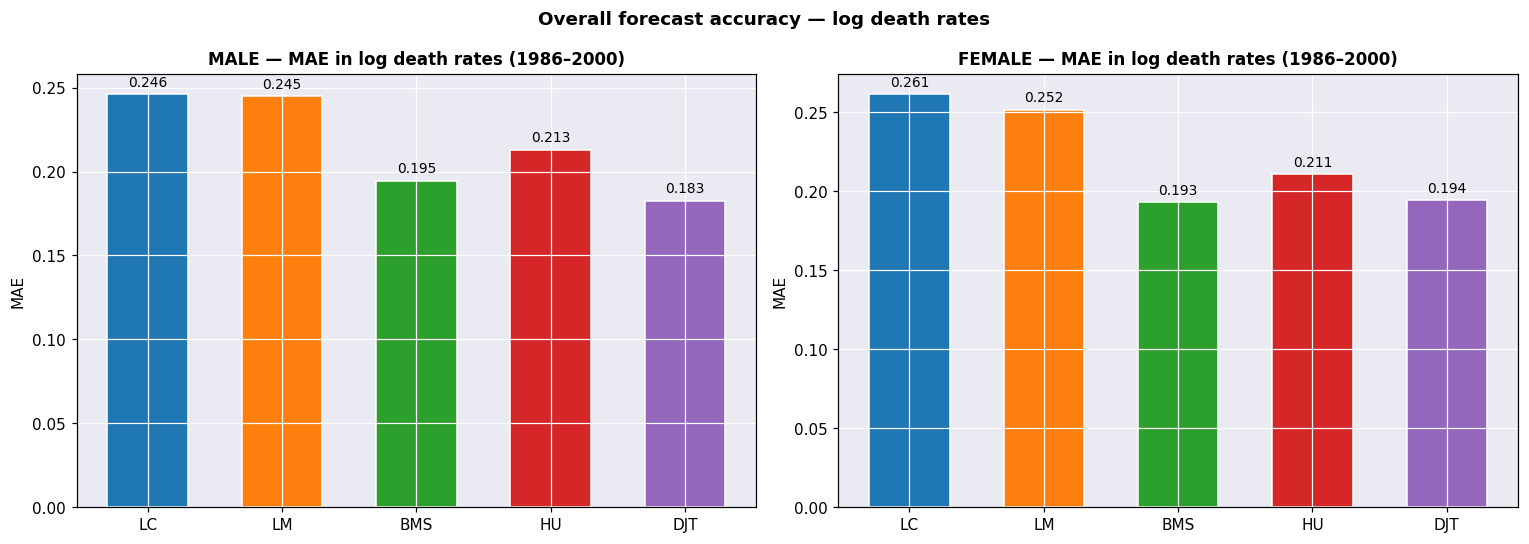

In [37]:
if not df_log.empty:
    _cmap = plt.get_cmap("tab10")
    mcolors = {m: _cmap(i) for i, m in enumerate(METHODS)}
    linestyles = {"LC":"-","LM":"-.","BMS":"--","HU":":","DJT":(0,(3,1,1,1))}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for si, sex in enumerate(SEXES):
        ax = axes[si]
        sub = df_log[df_log["Sex"]==sex].groupby("Method")["MAE"].mean()
        bars = ax.bar(METHODS, [sub.get(m, 0) for m in METHODS],
                      color=[mcolors[m] for m in METHODS], edgecolor="white", width=0.6)
        ax.set_title(f"{sex.upper()} — MAE in log death rates ({EVAL_START}–{EVAL_END})")
        ax.set_ylabel("MAE"); ax.set_ylim(0)
        for bar, m in zip(bars, METHODS):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
    plt.suptitle("Overall forecast accuracy — log death rates", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

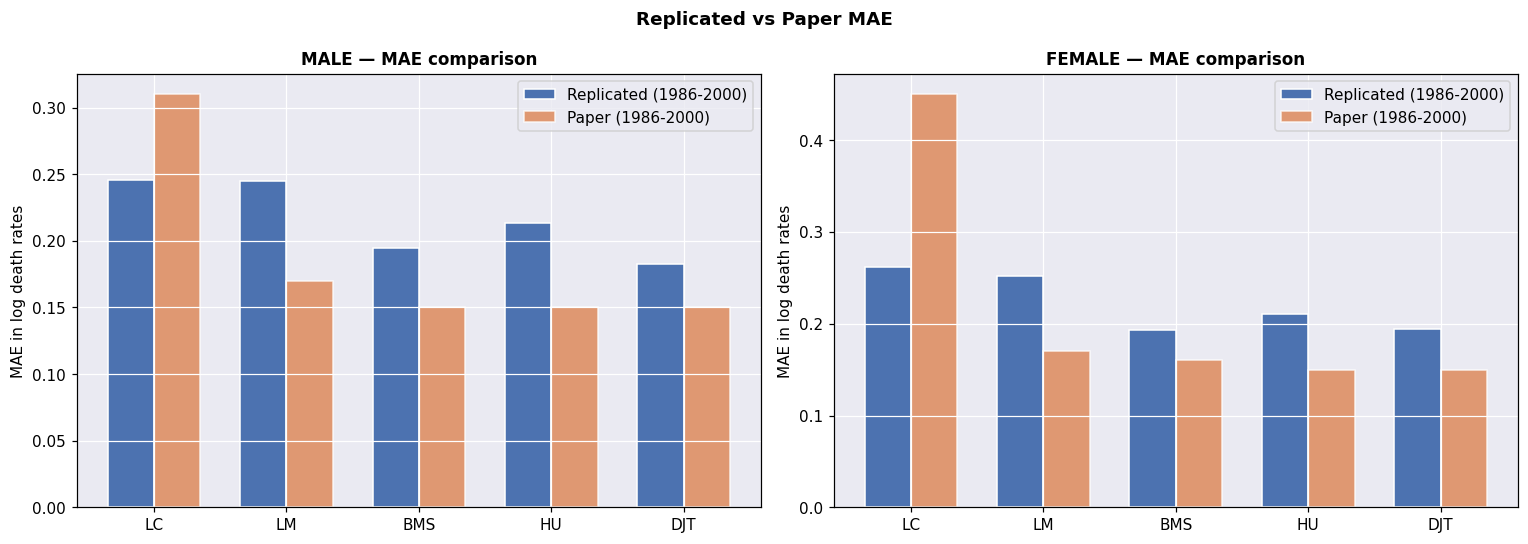

In [38]:
# Summary comparison: replicated vs paper averages
if not df_log.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    paper_mae = {
        "male":   {"LC":0.31,"LM":0.17,"BMS":0.15,"HU":0.15,"DJT":0.15},
        "female": {"LC":0.45,"LM":0.17,"BMS":0.16,"HU":0.15,"DJT":0.15},
    }
    x = np.arange(len(METHODS)); w = 0.35
    for si, sex in enumerate(SEXES):
        ax = axes[si]
        rep = df_log[df_log["Sex"]==sex].groupby("Method")["MAE"].mean()
        rep_vals = [rep.get(m, np.nan) for m in METHODS]
        pap_vals = [paper_mae[sex][m] for m in METHODS]
        ax.bar(x - w/2, rep_vals, w, label=f"Replicated ({EVAL_START}-{EVAL_END})",
               color="#4C72B0", edgecolor="white")
        ax.bar(x + w/2, pap_vals, w, label="Paper (1986-2000)",
               color="#DD8452", edgecolor="white", alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(METHODS)
        ax.set_title(f"{sex.upper()} — MAE comparison")
        ax.set_ylabel("MAE in log death rates"); ax.legend()
    plt.suptitle("Replicated vs Paper MAE", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()